Saving Numeros_Favoreecidos_2019_2025_Loteria_Popular_d95e222a6d (1).xlsx to Numeros_Favoreecidos_2019_2025_Loteria_Popular_d95e222a6d (1) (13).xlsx

569 sorteos cargados, del 2019-01-04 al 2025-12-02

X (variables): (500, 300)
y (objetivo): (500, 100)

Exactitud del modelo: 96.98%
Exactitud esperada solo por azar: 3.00%

-------------------------------------------------------------------------
Numero recomendado: 33
Probabilidad estimada: 26.39%
-------------------------------------------------------------------------

Los 10 numeros más probables:
 numero  probabilidad
     33      0.263869
     73      0.236985
      3      0.196841
     74      0.189839
     77      0.184825
     44      0.174660
     56      0.167333
     52      0.166304
      0      0.165042
     15      0.164333


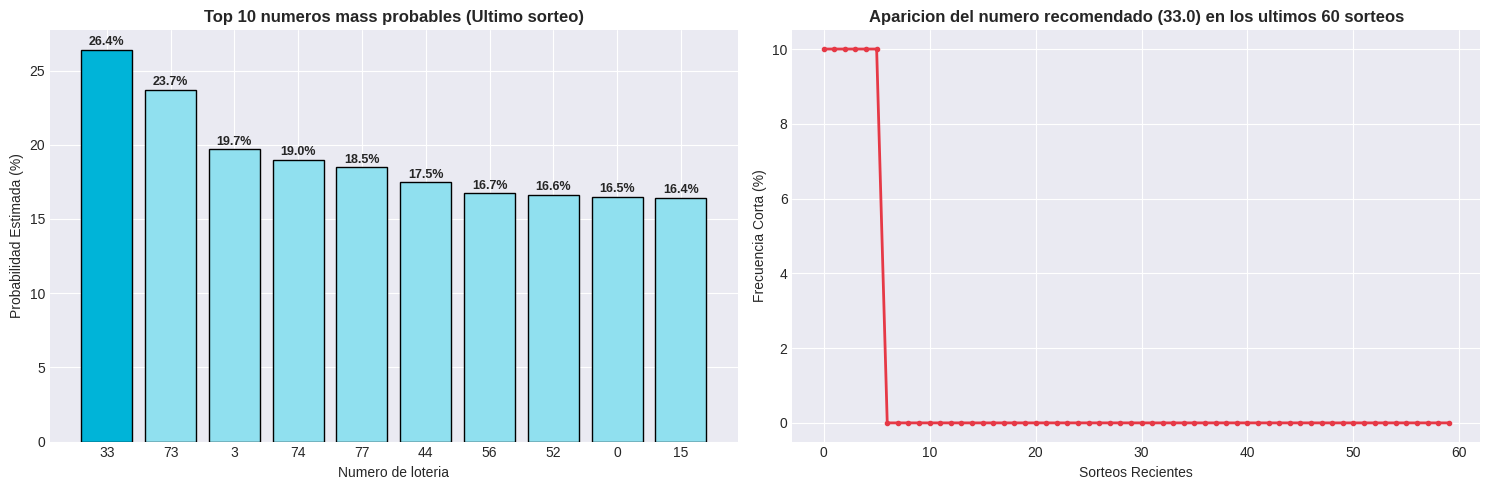

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###--- Keneth Josue Varela Ruíz, Grupo 4 ---###

uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]

df = pd.read_excel(nombre_archivo, sheet_name=0)
df = df.dropna(axis=1, how="all")  # quita columnas vacías
df.columns = [str(c).strip() for c in df.columns]

col_fecha = [c for c in df.columns if "Fecha" in c][0]
df[col_fecha] = pd.to_datetime(df[col_fecha])
df = df.sort_values(col_fecha).reset_index(drop=True)

cols_numeros = [c for c in df.columns if "Número" in c and "Sorteo" not in c]

print(f"\n{len(df)} sorteos cargados, del {df[col_fecha].min().date()} al {df[col_fecha].max().date()}")

#Convertir a formato de tabla binaria
rango_numeros=list(range(100))
binaria=pd.DataFrame(0,index=df.index,columns=rango_numeros)

for c in cols_numeros:
  for idx, val in df[c].items():
    if pd.notna(val):
      binaria.loc[idx,int(val)]=1

binaria.head()

##Crear las variable (features)

VENTANA_CORTA = 5
VENTANA_LARGA = 20
N_SORTEOS = 500

muestra = binaria.tail(N_SORTEOS).reset_index(drop=True)

features_dict = {}

for num in rango_numeros:
    # Frecuencia de los ultimos 5 sorteos para capturar la racha reciente
    features_dict[f"freq_corta_{num}"] = muestra[num].rolling(VENTANA_CORTA, min_periods=1).mean().shift(1).fillna(0)

    features_dict[f"freq_larga_{num}"] = muestra[num].rolling(VENTANA_LARGA, min_periods=1).mean().shift(1).fillna(0)

    s = muestra[num].shift(1).fillna(0)
    silencio = (s == 0).astype(int).groupby((s != 0).cumsum()).cumsum()
    features_dict[f"silencio_{num}"] = silencio

X = pd.DataFrame(features_dict)
y = muestra
print("\nX (variables):", X.shape)
print("y (objetivo):", y.shape)

#Entrenar al modelo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

modelo = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4, random_state=42))
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

#Evaluar el modelo
from sklearn.metrics import accuracy_score

exactitud_modelo = accuracy_score(y_test.values.ravel(), pred.ravel())
exactitud_azar = 3 / 100

print(f"\nExactitud del modelo: {exactitud_modelo:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")

# predict_proba devuelve una lista de arrays de forma (n_muestras, 2) por cada numero
probs_list = modelo.predict_proba(X_test)

# Extrae ña probabilidad de X_test
probs_ultimo_sorteo = [prob[-1, 1] for prob in probs_list]

# DataFrame con las probabilidades por cada numero
df_probs = pd.DataFrame({
    'numero': rango_numeros,
    'probabilidad': probs_ultimo_sorteo
})

# top 10 para tener el orden
top_10 = df_probs.sort_values(by='probabilidad', ascending=False).head(10).reset_index(drop=True)
num_top = top_10.iloc[0]['numero']
prob_top = top_10.iloc[0]['probabilidad']

print("\n-------------------------------------------------------------------------")
print(f"Numero recomendado: {int(num_top)}")
print(f"Probabilidad estimada: {prob_top:.2%}")
print("-------------------------------------------------------------------------\n")

print("Los 10 numeros más probables:")
print(top_10.to_string(index=False))


plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Barplot Top 10 Números
colores = ['#00b4d8' if i == 0 else '#90e0ef' for i in range(10)]
axes[0].bar(top_10['numero'].astype(str), top_10['probabilidad'] * 100, color=colores, edgecolor='black')
axes[0].set_title("Top 10 numeros mass probables (Ultimo sorteo)", fontweight='bold')
axes[0].set_xlabel("Numero de loteria")
axes[0].set_ylabel("Probabilidad Estimada (%)")

for i, v in enumerate(top_10['probabilidad']):
    axes[0].text(i, (v * 100) + 0.3, f"{v:.1%}", ha='center', fontweight='bold', fontsize=9)

# Gráfico 2: Histórico de Frecuencia del Número Recomendado
frec_historica = muestra[num_top].rolling(10, min_periods=1).mean() * 100
axes[1].plot(frec_historica.tail(60).values, color='#e63946', linewidth=2, marker='o', markersize=3)
axes[1].set_title(f"Aparicion del numero recomendado ({num_top}) en los ultimos 60 sorteos", fontweight='bold')
axes[1].set_xlabel("Sorteos Recientes")
axes[1].set_ylabel("Frecuencia Corta (%)")

plt.tight_layout()
plt.show()